# Leaf Pest / Disease Severity — SAM 3 only

Every stage of this pipeline is SAM 3. There is no LAB colour-anomaly layer, no
thresholded pixel statistics, no hand-tuned colour constants. Leaf selection,
damage detection, and background rejection are all promptable concept
segmentation calls.

| Stage | Mechanism |
|---|---|
| Leaf selection | SAM 3 text prompt `"leaf"`, multi-instance, explicit target choice |
| Damage detection | SAM 3 text prompts (short noun phrases), one concept per call |
| Recall recovery | SAM 3 **image exemplars**, auto-seeded from the model's own top detections |
| Resolution recovery | SAM 3 run on overlapping tiles, merged by mask NMS |
| False-positive rejection | SAM 3 **distractor prompts**, subtracted |

### Read this before trusting a number

SAM 3's detector predicts a bounded set of **discrete instances**. On a dense
carpet of small touching pests (spider mites, heavy aphid colonies) it will
individuate some and merge or miss others, so the reported affected *area* is a
**lower bound**, not an unbiased estimate. This is a property of the whole
DETR-style detector family, not a bug in this notebook. A per-pixel colour test
does not have that failure mode — which is exactly why the earlier hybrid
version kept one.

Removing it buys you something real: every pixel counted as damage is now
attributable to a named concept with a confidence score and an instance ID, so
you can audit *why* an image scored what it did. It costs you area recall on
dense infestations. If your images are dominated by that case, prefer instance
**count** (reported below alongside area) — for countable pests it is the more
stable metric anyway, and it does not depend on how tightly SAM 3 traced each
body.

### Prompt style matters more than any threshold

SAM 3 is trained on **short noun phrases** ("yellow school bus"). Descriptive,
Grounding-DINO-style prompts degrade it:

- `"cluster of small green insects on a leaf"` → diffuse text embedding, presence head suppresses it
- `"aphid"` → works

Rules used throughout this notebook: 1–3 words, singular head noun, at most one
*visual* modifier, never name the substrate ("on leaf"), never use a group noun
("cluster of" makes it segment the hull rather than the members — SAM 3 already
returns every instance).

There is also no phrase concatenation and no text-token competition in SAM 3, so
`"a . b . c"` chunking and negative-phrase down-weighting (both Grounding DINO
mechanics) do not apply. Distractors are run as their own passes and subtracted.

## 1 · Setup

In [1]:
!pip install -q "numpy<2.0" opencv-python-headless scipy matplotlib
!pip install -q 'git+https://github.com/facebookresearch/sam3.git'

# sam3 pins numpy < 2.0. If this cell just downgraded numpy in a fresh Colab
# session, restart the runtime (Runtime > Restart session) before continuing,
# then skip re-running this install cell.
print("If NumPy was just installed/downgraded, restart the runtime now, then continue.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 78.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 23.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dm-tree 0.1.10 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.8.23 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.11.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.

**SAM 3 checkpoints are gated.** Request access at the
[SAM 3 Hugging Face repo](https://huggingface.co/facebook/sam3) and authenticate
once per environment.

In [ ]:
# from huggingface_hub import login
# login()  # paste an access token with access to facebook/sam3

In [1]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

import sam3
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import normalize_bbox

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE != "cuda":
    print("WARNING: no CUDA device. SAM3 defaults to device='cuda' internally and is not "
          "validated on CPU-only setups — expect this to be very slow or to fail. "
          "This notebook makes many forward passes (one per prompt, more with tiling), "
          "so a GPU runtime matters more here than in the single-prompt examples.")
else:
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

print("Device:", DEVICE)

/usr/local/lib/python3.13/dist-packages/sam3/model/model_misc.py:71: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Device: cuda


## 2 · Build model

In [2]:
sam3_root = os.path.dirname(sam3.__file__)
bpe_path = os.path.join(sam3_root, "assets", "bpe_simple_vocab_16e6.txt.gz")

model = build_sam3_image_model(bpe_path=bpe_path, device=DEVICE)

# confidence_threshold is set per-call by sam3_detect() below; this initial value
# is just the constructor default and gets overridden.
processor = Sam3Processor(model, device=DEVICE, confidence_threshold=0.30)
print("Ready.")

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

Ready.


## 3 · Load an image

In [3]:
# Colab:
from google.colab import files
uploaded = files.upload()
IMG_PATH = list(uploaded.keys())[0]

# Local / non-Colab: comment out the three lines above and set the path directly.
# IMG_PATH = "citrus_citrusblackfly_00222.jpeg"

image = Image.open(IMG_PATH).convert("RGB")
img_w, img_h = image.size
rgb = np.array(image)
print(f"Loaded: {IMG_PATH}  ({img_w} x {img_h})")

Saving citrus_citrusblackfly_00222.jpeg to citrus_citrusblackfly_00222.jpeg
Loaded: citrus_citrusblackfly_00222.jpeg  (548 x 345)


## 4 · Configuration

`TARGET` selects which prompt families run. Every phrase costs one forward pass,
so trimming the list to the pests you actually expect is the cheapest speedup
available — and it also raises precision, since an unused phrase can only ever
contribute false positives.

In [4]:
TARGET = "insect"          # "insect" | "lesion" | "both"

# ---- Concept prompts: short noun phrases only -------------------------------
INSECT_PROMPTS = {
    "aphid":             ["aphid", "green aphid", "black aphid"],
    "whitefly":          ["whitefly", "white insect", "white fly"],
    "scale_mealybug":    ["scale insect", "mealybug", "black scale insect",
                          "white waxy insect", "black oval insect"],
    "larva_caterpillar": ["caterpillar", "larva", "grub", "green worm"],
    "beetle_bug":        ["beetle", "black beetle", "small insect", "bug"],
    "egg_mass":          ["insect egg", "yellow egg", "dark egg"],
}

LESION_PROMPTS = {
    "lesion_spot":  ["leaf spot", "brown spot", "necrotic lesion", "blight patch"],
    "rust_pustule": ["rust pustule", "orange pustule", "yellow rust spot"],
    "chlorosis":    ["yellow patch", "chlorotic leaf"],
}

# Distractors are NOT competitors (SAM 3 has no text-token scoring). They are run
# as independent passes and their masks are subtracted from the damage mask.
DISTRACTOR_PROMPTS = [
    "leaf vein", "midrib", "water droplet", "dew drop",
    "finger", "human hand", "soil", "stem",
]

LEAF_PROMPT = "leaf"       # try "citrus leaf", "grape leaf" if the crop is known

# ---- Thresholds -------------------------------------------------------------
# SAM 3 exposes ONE detection confidence. There is no box/text threshold pair.
CONF            = 0.30     # damage prompts. 0.5 (the library default) drops most small pests
LEAF_CONF       = 0.40     # leaf prompt can afford to be stricter
DISTRACTOR_CONF = 0.35     # be conservative: a false distractor erases real damage

NMS_IOU         = 0.55     # mask-level dedupe across synonym phrases
LEAF_COVER      = 0.30     # min fraction of an instance that must sit on the target leaf
MAX_INSTANCE_FRAC = 0.25   # reject instances larger than this fraction of leaf area
MIN_PX          = 12       # reject specks below this on-leaf pixel count

# ---- Recall recovery --------------------------------------------------------
USE_EXEMPLAR_BOOTSTRAP = True   # feed SAM3's own best detections back as image exemplars
N_SEED                 = 3      # how many top-scoring detections to use as exemplars

USE_DISTRACTOR_SUBTRACTION = True

TILING              = "auto"    # "auto" | "always" | "never"
TILE                = 640
TILE_OVERLAP        = 0.25
MIN_SIDE_FOR_TILING = 1400      # below this, tiling upscales nothing and only adds seams

MIN_LEAF_FRACTION = 0.15        # plausibility guard on the selected leaf

# ---- Derived ----------------------------------------------------------------
_ACTIVE = {}
if TARGET in ("insect", "both"):
    _ACTIVE.update(INSECT_PROMPTS)
if TARGET in ("lesion", "both"):
    _ACTIVE.update(LESION_PROMPTS)

PHRASE2CLASS = {p: c for c, phrases in _ACTIVE.items() for p in phrases}
CLASSES      = list(_ACTIVE.keys())

print(f"TARGET={TARGET}  ->  {len(CLASSES)} class(es), {len(PHRASE2CLASS)} phrase(s), "
      f"{len(DISTRACTOR_PROMPTS)} distractor(s)")
print(f"Forward passes this run: ~{len(PHRASE2CLASS)} "
      f"+ {len(CLASSES) if USE_EXEMPLAR_BOOTSTRAP else 0} (exemplar) "
      f"+ {len(DISTRACTOR_PROMPTS) if USE_DISTRACTOR_SUBTRACTION else 0} (distractor) + 1 (leaf)")

TARGET=insect  ->  6 class(es), 22 phrase(s), 8 distractor(s)
Forward passes this run: ~22 + 6 (exemplar) + 8 (distractor) + 1 (leaf)


## 5 · Helpers

`masks_to_numpy` pulls the raw arrays out of a `Sam3Processor` state — the
official example only calls `plot_results()`, which is visualization-only.

The `.to(torch.float32)` cast is required: under the bfloat16 autocast entered
in Setup, these tensors come back as bf16, and NumPy has no bf16 dtype, so a
direct `.cpu().numpy()` raises `TypeError: Got unsupported ScalarType BFloat16`.

`nms_masks` deduplicates at the **mask** level, not the box level. Touching
pests have heavily overlapping boxes but disjoint masks; box NMS would delete
real detections.

In [5]:
def masks_to_numpy(state):
    """(masks[N,H,W] bool, boxes[N,4] xyxy px, scores[N]) from a Sam3Processor state."""
    if "masks" not in state or state["masks"].shape[0] == 0:
        h, w = state["original_height"], state["original_width"]
        return np.zeros((0, h, w), bool), np.zeros((0, 4)), np.zeros((0,))
    masks  = state["masks"].squeeze(1).detach().to(torch.float32).cpu().numpy().astype(bool)
    boxes  = state["boxes"].detach().to(torch.float32).cpu().numpy()
    scores = state["scores"].detach().to(torch.float32).cpu().numpy()
    return masks, boxes, scores


def sam3_detect(prompt, conf, state=None, pil_image=None, exemplars=None):
    """One SAM 3 concept prompt.

    Pass `state` to reuse an already-encoded image (cheap: skips the backbone).
    Pass `pil_image` instead when running on a crop, which needs its own encode.

    exemplars: list of (xywh_box, label_bool) combined WITH the text prompt.
    Text + exemplar together outperforms either alone on hard concepts.
    """
    processor.confidence_threshold = conf

    if state is None:
        state = processor.set_image(pil_image)
    processor.reset_all_prompts(state)
    state = processor.set_text_prompt(prompt=prompt, state=state)

    if exemplars:
        w = state["original_width"]
        h = state["original_height"]
        for box_xywh, label in exemplars:
            b = box_xywh_to_cxcywh(torch.tensor(box_xywh, dtype=torch.float32).view(-1, 4))
            state = processor.add_geometric_prompt(
                state=state, box=normalize_bbox(b, w, h).flatten().tolist(), label=bool(label)
            )

    return masks_to_numpy(state)


def bbox_of(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return np.zeros(4)
    return np.array([xs.min(), ys.min(), xs.max(), ys.max()], float)


def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    if inter == 0:
        return 0.0
    return inter / float(np.logical_or(a, b).sum())


def nms_masks(masks, scores, labels=None, iou_th=NMS_IOU):
    """Greedy mask-level NMS, highest score first."""
    if len(masks) == 0:
        return masks, scores, (labels or [])
    order = np.argsort(-scores)
    kept = []
    for i in order:
        if all(mask_iou(masks[i], masks[j]) < iou_th for j in kept):
            kept.append(int(i))
    kept = np.array(kept, dtype=int)
    return masks[kept], scores[kept], ([labels[i] for i in kept] if labels else [])


def filter_instances(masks, boxes, scores, leaf_mask,
                     leaf_cover=LEAF_COVER, max_frac=MAX_INSTANCE_FRAC, min_px=MIN_PX):
    """Keep only detections that are plausibly damage ON the target leaf.

    These are containment/size constraints on SAM 3's own output — not an
    independent detector. Precision comes from here rather than from raising
    `conf`, because a higher confidence threshold removes small true positives
    before it removes large false ones.
    """
    if len(masks) == 0:
        return masks, boxes, scores
    leaf_area = float(leaf_mask.sum()) or 1.0
    keep = []
    for i, m in enumerate(masks):
        on = m & leaf_mask
        a = float(on.sum())
        if a < min_px:
            continue
        if m.sum() and a / float(m.sum()) < leaf_cover:   # mostly off-leaf
            continue
        if a / leaf_area > max_frac:                      # it re-segmented the leaf
            continue
        keep.append(i)
    keep = np.array(keep, dtype=int)
    return masks[keep], boxes[keep], scores[keep]

## 6 · Step 1 — Leaf selection

SAM 3 returns every leaf instance in frame. The target is chosen explicitly:
among instances whose box contains the image centre, take the largest. If none
contain the centre, fall back to the largest leaf overall and say so, rather
than silently scoring the wrong object.

The mask is eroded slightly before use. The outermost few pixels of a leaf mask
straddle the boundary, and any detection clipped there would otherwise be
credited as on-leaf damage.

In [6]:
def pick_target_leaf(masks, boxes, img_w, img_h):
    if len(masks) == 0:
        return None, "no_leaf_found"
    cx, cy = img_w / 2.0, img_h / 2.0
    areas = masks.reshape(len(masks), -1).sum(axis=1)
    contains_center = (
        (boxes[:, 0] <= cx) & (cx <= boxes[:, 2]) &
        (boxes[:, 1] <= cy) & (cy <= boxes[:, 3])
    )
    if contains_center.any():
        pool = np.where(contains_center)[0]
        return int(pool[np.argmax(areas[pool])]), "centered"
    return int(np.argmax(areas)), "largest_fallback_not_centered"


LEAF_ERODE_PX = 3

# Encode the image once. Every full-frame prompt below reuses this state.
state = processor.set_image(image)

leaf_masks, leaf_boxes, leaf_scores = sam3_detect(LEAF_PROMPT, LEAF_CONF, state=state)
print(f"'{LEAF_PROMPT}' -> {len(leaf_masks)} instance(s)")
for i, s in enumerate(leaf_scores):
    print(f"  leaf[{i}]  score={s:.2f}  area={int(leaf_masks[i].sum()):,} px")

target_idx, reason = pick_target_leaf(leaf_masks, leaf_boxes, img_w, img_h)
if target_idx is None:
    raise RuntimeError(
        f"No '{LEAF_PROMPT}' instance found. Try a crop-specific prompt "
        f"(e.g. 'citrus leaf') or lower LEAF_CONF and re-run."
    )

leaf_mask = ndimage.binary_fill_holes(leaf_masks[target_idx])
if LEAF_ERODE_PX > 0:
    leaf_mask = ndimage.binary_erosion(leaf_mask, np.ones((3, 3)), iterations=LEAF_ERODE_PX)

print(f"\nSelected leaf #{target_idx} ({reason}) — {100 * leaf_mask.mean():.1f}% of frame")
n_other = len(leaf_masks) - 1
if n_other > 0:
    print(f"{n_other} other leaf instance(s) excluded as background.")

if leaf_mask.mean() < MIN_LEAF_FRACTION:
    print(f"\nWARNING: selected leaf covers only {100 * leaf_mask.mean():.1f}% of the frame. "
          f"Likely heavy occlusion or wrong framing — severity is a percentage of a "
          f"near-zero denominator and is not meaningful for this image.")

'leaf' -> 4 instance(s)
  leaf[0]  score=0.43  area=31,688 px
  leaf[1]  score=0.58  area=6,829 px
  leaf[2]  score=0.71  area=15,827 px
  leaf[3]  score=0.93  area=129,826 px

Selected leaf #3 (centered) — 78.8% of frame
3 other leaf instance(s) excluded as background.


## 7 · Step 2 — Damage detection

One forward pass per phrase. Synonyms are kept deliberately: different phrasings
fire on genuinely different instances, and mask NMS merges the overlap
afterwards. What is *not* kept is phrase length — see the note at the top.

Tiling is applied only when the image is large enough to benefit. SAM 3 resizes
the frame to roughly 1000 px before the detector runs, so a 3 mm insect in a
4000 px phone photo lands on two or three pixels and is unrecoverable; tiling
restores native resolution. On a small image (the citrus blackfly sample is
548×345) the frame *upscales* on the way in, and tiling would only add seam
artifacts and cost time.

In [7]:
def detect_prompt(prompt, conf, leaf_mask, exemplars=None):
    """Full-frame or tiled detection for one phrase, filtered to the target leaf."""
    use_tiles = (TILING == "always") or (TILING == "auto" and max(img_w, img_h) >= MIN_SIDE_FOR_TILING)

    if not use_tiles:
        m, b, s = sam3_detect(prompt, conf, state=state, exemplars=exemplars)
        return filter_instances(m, b, s, leaf_mask)

    step = max(int(TILE * (1 - TILE_OVERLAP)), 1)
    xs = list(range(0, max(img_w - TILE, 0) + 1, step))
    ys = list(range(0, max(img_h - TILE, 0) + 1, step))
    if xs[-1] + TILE < img_w: xs.append(img_w - TILE)
    if ys[-1] + TILE < img_h: ys.append(img_h - TILE)

    all_m, all_s = [], []
    for y in ys:
        for x in xs:
            x2, y2 = min(x + TILE, img_w), min(y + TILE, img_h)
            if not leaf_mask[y:y2, x:x2].any():
                continue                      # no leaf in this tile, skip the pass
            crop = image.crop((x, y, x2, y2))
            m, _, s = sam3_detect(prompt, conf, pil_image=crop, exemplars=None)
            for mi, si in zip(m, s):
                full = np.zeros((img_h, img_w), bool)
                full[y:y2, x:x2] = mi
                all_m.append(full)
                all_s.append(float(si))

    if not all_m:
        return np.zeros((0, img_h, img_w), bool), np.zeros((0, 4)), np.zeros((0,))

    masks  = np.stack(all_m)
    scores = np.array(all_s)
    masks, scores, _ = nms_masks(masks, scores, iou_th=0.45)   # merge seam duplicates
    boxes  = np.array([bbox_of(m) for m in masks])
    return filter_instances(masks, boxes, scores, leaf_mask)


inst_masks, inst_scores, inst_labels, inst_phrases = [], [], [], []
prompt_report = []

for phrase, cls in PHRASE2CLASS.items():
    m, b, s = detect_prompt(phrase, CONF, leaf_mask)
    for mi, si in zip(m, s):
        inst_masks.append(mi & leaf_mask)
        inst_scores.append(float(si))
        inst_labels.append(cls)
        inst_phrases.append(phrase)
    prompt_report.append({
        "phrase": phrase, "class": cls, "kept": len(m),
        "avg_score": float(s.mean()) if len(s) else 0.0,
        "px": int(sum(int((mi & leaf_mask).sum()) for mi in m)),
    })

print(f"{'Phrase':<22}{'Class':<20}{'Kept':<7}{'AvgScore':<11}{'Px on leaf':<10}")
for r in prompt_report:
    print(f"{r['phrase']:<22}{r['class']:<20}{r['kept']:<7}{r['avg_score']:<11.2f}{r['px']:<10,}")
print(f"\nRaw instances before NMS: {len(inst_masks)}")

Phrase                Class               Kept   AvgScore   Px on leaf
aphid                 aphid               53     0.84       19,666    
green aphid           aphid               0      0.00       0         
black aphid           aphid               51     0.82       19,514    
whitefly              whitefly            0      0.00       0         
white insect          whitefly            0      0.00       0         
white fly             whitefly            0      0.00       0         
scale insect          scale_mealybug      0      0.00       0         
mealybug              scale_mealybug      0      0.00       0         
black scale insect    scale_mealybug      50     0.68       27,428    
white waxy insect     scale_mealybug      0      0.00       0         
black oval insect     scale_mealybug      48     0.68       18,597    
caterpillar           larva_caterpillar   0      0.00       0         
larva                 larva_caterpillar   0      0.00       0         
grub  

## 8 · Step 3 — Exemplar bootstrapping

This is the strongest lever SAM 3 offers and the main thing replacing the
colour layer's recall.

The text pass finds the most obvious members of a colony. Their boxes are then
fed back as **positive image exemplars** alongside the same text prompt, so SAM 3
re-queries the image for things that look like *these specific objects* rather
than like the phrase. Faint, partially occluded, and touching members that the
text embedding alone scored below threshold get picked up on the second pass.

Seeds come from the model's own top-scoring detections, so no manual box-drawing
is required — the usual reason exemplar refinement stays unused in practice.

In [8]:
if USE_EXEMPLAR_BOOTSTRAP and len(inst_masks):
    added_total = 0
    for cls in CLASSES:
        idx = [i for i, l in enumerate(inst_labels) if l == cls]
        if not idx:
            continue

        # best detections for this class become the exemplars
        idx = sorted(idx, key=lambda i: -inst_scores[i])[:N_SEED]
        exemplars = []
        for i in idx:
            x1, y1, x2, y2 = bbox_of(inst_masks[i])
            if x2 <= x1 or y2 <= y1:
                continue
            exemplars.append(([float(x1), float(y1), float(x2 - x1), float(y2 - y1)], True))
        if not exemplars:
            continue

        # re-query with the class's primary (shortest, most canonical) phrase
        primary = _ACTIVE[cls][0]
        m, b, s = detect_prompt(primary, CONF, leaf_mask, exemplars=exemplars)

        before = len(inst_masks)
        for mi, si in zip(m, s):
            inst_masks.append(mi & leaf_mask)
            inst_scores.append(float(si))
            inst_labels.append(cls)
            inst_phrases.append(f"{primary} +exemplar")
        added_total += len(inst_masks) - before
        print(f"  {cls:<20} seeded {len(exemplars)} exemplar(s) -> {len(m)} instance(s) returned")

    print(f"\nInstances after exemplar bootstrap (pre-NMS): {len(inst_masks)} (+{added_total})")
else:
    print("Exemplar bootstrap skipped.")

  aphid                seeded 3 exemplar(s) -> 51 instance(s) returned
  scale_mealybug       seeded 3 exemplar(s) -> 48 instance(s) returned
  beetle_bug           seeded 3 exemplar(s) -> 48 instance(s) returned

Instances after exemplar bootstrap (pre-NMS): 447 (+147)


## 9 · Step 4 — Deduplicate

Synonym phrases and the exemplar pass all describe the same physical objects.
Mask NMS collapses them into one instance each, keeping the highest-scoring
detection and its class label.

In [9]:
if len(inst_masks):
    M = np.stack(inst_masks)
    S = np.array(inst_scores)
    M, S, L = nms_masks(M, S, labels=inst_labels, iou_th=NMS_IOU)
else:
    M = np.zeros((0, img_h, img_w), bool)
    S = np.zeros((0,))
    L = []

print(f"Instances after NMS: {len(M)}")
if len(L):
    for cls in CLASSES:
        n = sum(1 for l in L if l == cls)
        if n:
            sc = [S[i] for i, l in enumerate(L) if l == cls]
            print(f"  {cls:<20} {n:>4} instance(s)   mean score {np.mean(sc):.2f}")

Instances after NMS: 53
  aphid                  47 instance(s)   mean score 0.86
  scale_mealybug          2 instance(s)   mean score 0.64
  beetle_bug              4 instance(s)   mean score 0.83


## 10 · Step 5 — Distractor subtraction

SAM 3 has no equivalent of Grounding DINO's text-token competition, so a
distractor phrase cannot down-weight a target detection. Distractors are
therefore run as their own concept passes, and the resulting mask is subtracted.

`"leaf vein"` and `"midrib"` are the two that earn their keep: a glossy midrib
running down a curved leaf is the single most common false positive in this
task. `DISTRACTOR_CONF` is deliberately higher than `CONF` — an over-eager
distractor deletes real damage, which is the more expensive error here.

An instance is dropped only if the distractor claims most of it; partial overlap
just trims the mask.

In [10]:
DISTRACTOR_KILL_FRAC = 0.60   # drop an instance if this much of it is claimed

if USE_DISTRACTOR_SUBTRACTION:
    distract = np.zeros((img_h, img_w), bool)
    for p in DISTRACTOR_PROMPTS:
        m, _, s = sam3_detect(p, DISTRACTOR_CONF, state=state)
        px_before = int(distract.sum())
        for mi in m:
            distract |= mi
        print(f"  {p:<16} {len(m):>3} instance(s)  +{int(distract.sum()) - px_before:,} px")

    keep, trimmed, dropped = [], 0, 0
    for i, mi in enumerate(M):
        a = float(mi.sum())
        if a == 0:
            continue
        clean = mi & ~distract
        if clean.sum() / a < (1.0 - DISTRACTOR_KILL_FRAC):
            dropped += 1
            continue
        if clean.sum() < a:
            trimmed += 1
        if clean.sum() >= MIN_PX:
            keep.append(i)
            M[i] = clean

    keep = np.array(keep, dtype=int)
    M, S, L = M[keep], S[keep], [L[i] for i in keep]
    print(f"\nDistractor pass: {dropped} instance(s) dropped, {trimmed} trimmed. "
          f"{len(M)} remain.")
else:
    distract = np.zeros((img_h, img_w), bool)
    print("Distractor subtraction skipped.")

  leaf vein          0 instance(s)  +0 px
  midrib             1 instance(s)  +7,051 px
  water droplet      0 instance(s)  +0 px
  dew drop           0 instance(s)  +0 px
  finger             1 instance(s)  +4,723 px
  human hand         0 instance(s)  +0 px
  soil               0 instance(s)  +0 px
  stem               0 instance(s)  +0 px

Distractor pass: 0 instance(s) dropped, 0 trimmed. 53 remain.


## 11 · Step 6 — Severity

Two numbers are reported, and they fail differently:

- **Area %** — the classic severity metric, and the one the grade scale uses.
  Sensitive to how tightly SAM 3 traced each body, and biased *low* on dense
  infestations where instances merge or drop out.
- **Instance count** — for countable pests this is the more robust of the two,
  since a detection either happens or does not, independent of mask tightness.

Where they disagree sharply, trust the count for pests and the area for lesions.

In [11]:
def grade(pct):
    if pct < 1:  return "0 - Healthy"
    if pct < 5:  return "1 - Trace"
    if pct < 15: return "2 - Mild"
    if pct < 35: return "3 - Moderate"
    return "4 - Severe"


damage_mask = np.zeros((img_h, img_w), bool)
for mi in M:
    damage_mask |= mi
damage_mask &= leaf_mask

leaf_px   = int(leaf_mask.sum())
damage_px = int(damage_mask.sum())
severity  = 100.0 * damage_px / leaf_px if leaf_px else 0.0

print(f"Leaf area        : {leaf_px:,} px")
print(f"Affected area    : {damage_px:,} px")
print(f"SEVERITY (area)  : {severity:.2f}%")
print(f"Grade            : {grade(severity)}")
print(f"Instances        : {len(M)}")
if len(M):
    areas = M.reshape(len(M), -1).sum(1)
    print(f"Median instance  : {np.median(areas):.0f} px")
    print(f"Density          : {1000.0 * len(M) / max(leaf_px, 1):.2f} instances / 1000 leaf px")
    print(f"Mean confidence  : {S.mean():.2f}")

print("\nNote: area is a LOWER BOUND. SAM 3 individuates discrete instances, so "
      "densely packed or overlapping damage is under-counted rather than over-counted.")

Leaf area        : 149,024 px
Affected area    : 18,503 px
SEVERITY (area)  : 12.42%
Grade            : 2 - Mild
Instances        : 53
Median instance  : 416 px
Density          : 0.36 instances / 1000 leaf px
Mean confidence  : 0.85

Note: area is a LOWER BOUND. SAM 3 individuates discrete instances, so densely packed or overlapping damage is under-counted rather than over-counted.


## 12 · Step 7 — Visualization

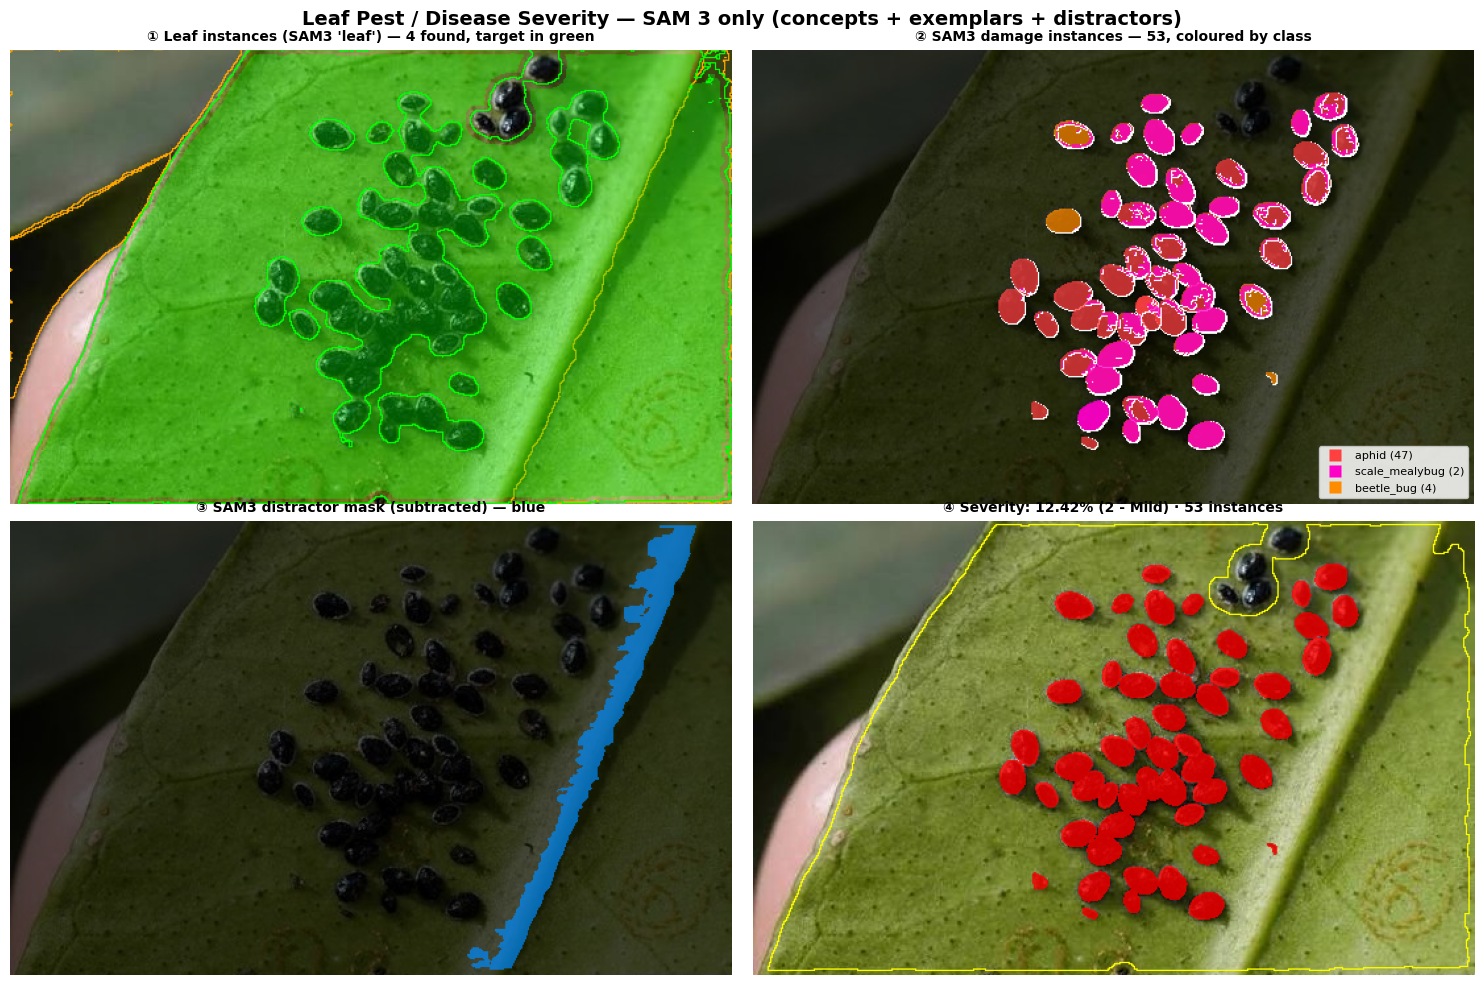

Per-instance detail (top 25 by score):
  [  0] beetle_bug           score=0.97  area=   468 px
  [  1] beetle_bug           score=0.97  area=   476 px
  [  2] beetle_bug           score=0.96  area=   390 px
  [  3] scale_mealybug       score=0.96  area=   424 px
  [  4] aphid                score=0.96  area=   440 px
  [  5] aphid                score=0.94  area=   433 px
  [  6] aphid                score=0.93  area=   415 px
  [  7] aphid                score=0.93  area=   394 px
  [  8] aphid                score=0.92  area=   466 px
  [  9] aphid                score=0.92  area=   425 px
  [ 10] aphid                score=0.92  area=   429 px
  [ 11] aphid                score=0.92  area=   486 px
  [ 12] aphid                score=0.92  area=   453 px
  [ 13] aphid                score=0.92  area=   384 px
  [ 14] aphid                score=0.92  area=   447 px
  [ 15] aphid                score=0.91  area=   387 px
  [ 16] aphid                score=0.91  area=   460 px
  [ 17] a

In [12]:
CLASS_COLORS = {
    "aphid":             (255, 64, 64),
    "whitefly":          (255, 255, 96),
    "scale_mealybug":    (255, 0, 200),
    "larva_caterpillar": (0, 220, 255),
    "beetle_bug":        (255, 140, 0),
    "egg_mass":          (180, 100, 255),
    "lesion_spot":       (255, 64, 64),
    "rust_pustule":      (255, 140, 0),
    "chlorosis":         (255, 255, 96),
}


def outline(mask, k=3):
    u8 = mask.astype(np.uint8)
    return (cv2.dilate(u8, np.ones((k, k))) - u8).astype(bool)


# Panel 1: leaf instances
leaf_view = rgb.copy()
for i, m in enumerate(leaf_masks):
    leaf_view[outline(m)] = (0, 255, 0) if i == target_idx else (255, 165, 0)
leaf_view[leaf_mask] = (0.65 * leaf_view[leaf_mask] + 0.35 * np.array([0, 255, 0])).astype(np.uint8)

# Panel 2: instances by class
inst_view = (0.35 * rgb).astype(np.uint8)
for mi, cls in zip(M, L):
    c = np.array(CLASS_COLORS.get(cls, (255, 0, 0)))
    inst_view[mi] = (0.25 * inst_view[mi] + 0.75 * c).astype(np.uint8)
    inst_view[outline(mi, 2)] = (255, 255, 255)

# Panel 3: what the distractor pass removed
dist_view = (0.35 * rgb).astype(np.uint8)
d_on_leaf = distract & leaf_mask
dist_view[d_on_leaf] = (0.3 * dist_view[d_on_leaf] + 0.7 * np.array([0, 140, 255])).astype(np.uint8)

# Panel 4: final
final = rgb.copy()
final[damage_mask] = (0.2 * final[damage_mask] + 0.8 * np.array([255, 0, 0])).astype(np.uint8)
final[outline(leaf_mask)] = (255, 255, 0)

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
panels = [
    (leaf_view, f"\u2460 Leaf instances (SAM3 '{LEAF_PROMPT}') — {len(leaf_masks)} found, target in green"),
    (inst_view, f"\u2461 SAM3 damage instances — {len(M)}, coloured by class"),
    (dist_view, "\u2462 SAM3 distractor mask (subtracted) — blue"),
    (final,     f"\u2463 Severity: {severity:.2f}% ({grade(severity)}) · {len(M)} instances"),
]
for a, (im, title) in zip(ax.ravel(), panels):
    a.imshow(im)
    a.set_title(title, fontsize=10, fontweight="bold")
    a.axis("off")

handles = [plt.Line2D([0], [0], marker="s", linestyle="", markersize=9,
                      markerfacecolor=np.array(CLASS_COLORS[c]) / 255.0, markeredgecolor="none",
                      label=f"{c} ({sum(1 for l in L if l == c)})")
           for c in CLASSES if any(l == c for l in L)]
if handles:
    ax[0, 1].legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.85)

plt.suptitle("Leaf Pest / Disease Severity — SAM 3 only (concepts + exemplars + distractors)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Per-instance detail (top 25 by score):")
for i in np.argsort(-S)[:25]:
    print(f"  [{i:>3}] {L[i]:<20} score={S[i]:.2f}  area={int(M[i].sum()):>6,} px")

## 13 · Optional — manual exemplar refinement

The automatic bootstrap in Step 3 seeds itself from the model's own detections,
which fails in one specific case: when the text pass found *nothing* to seed
from. If a pest is genuinely outside SAM 3's vocabulary, draw one box around a
confirmed example here and let the model find the rest by appearance alone.

A negative box is worth adding whenever there is a systematic lookalike in
frame — a specular highlight on the midrib, a water droplet, a scar.

In [13]:
# Inspect coordinates first:
# plt.figure(figsize=(10, 10)); plt.imshow(rgb); plt.grid(True); plt.show()

POSITIVE_EXEMPLAR_XYWH = None   # e.g. [420, 610, 60, 45]  — one confirmed pest/lesion
NEGATIVE_EXEMPLAR_XYWH = None   # e.g. [180, 300, 50, 50]  — a lookalike to push away
MANUAL_CLASS           = CLASSES[0]                 # which class the exemplar belongs to
MANUAL_PHRASE          = _ACTIVE[MANUAL_CLASS][0]   # short phrase to pair with the box

if POSITIVE_EXEMPLAR_XYWH is not None:
    ex = [(POSITIVE_EXEMPLAR_XYWH, True)]
    if NEGATIVE_EXEMPLAR_XYWH is not None:
        ex.append((NEGATIVE_EXEMPLAR_XYWH, False))

    m, b, s = detect_prompt(MANUAL_PHRASE, CONF, leaf_mask, exemplars=ex)
    print(f"Manual exemplar -> {len(m)} instance(s)")

    if len(m):
        M2 = np.concatenate([M, np.stack([mi & leaf_mask for mi in m])], 0)
        S2 = np.concatenate([S, s])
        L2 = L + [MANUAL_CLASS] * len(m)
        M, S, L = nms_masks(M2, S2, labels=L2, iou_th=NMS_IOU)

        damage_mask = np.zeros((img_h, img_w), bool)
        for mi in M:
            damage_mask |= mi
        damage_mask &= leaf_mask
        damage_px = int(damage_mask.sum())
        severity = 100.0 * damage_px / leaf_px if leaf_px else 0.0
        print(f"Updated severity: {severity:.2f}% ({grade(severity)}) over {len(M)} instances")
        print("Re-run the visualization cell to see the change.")
else:
    print("Skipped — set POSITIVE_EXEMPLAR_XYWH to use this.")

Skipped — set POSITIVE_EXEMPLAR_XYWH to use this.


## 14 · Tuning notes

**Tune in this order.** Prompt wording first, then `CONF`, then the containment
filters. Wording moves results more than any threshold.

| Symptom | Change |
|---|---|
| Nothing detected | Shorten the phrase. `"black oval insect"` → `"scale insect"`. Then drop `CONF` to 0.20 |
| Whole leaf returned as one instance | `MAX_INSTANCE_FRAC` down to 0.10; drop phrases naming the substrate |
| Midrib / veins counted as damage | Confirm `"leaf vein"` and `"midrib"` are in `DISTRACTOR_PROMPTS`; raise `DISTRACTOR_KILL_FRAC` |
| Real damage being erased | Lower `DISTRACTOR_KILL_FRAC`, or raise `DISTRACTOR_CONF` to 0.45 |
| Same pest counted twice | Raise `NMS_IOU` toward 0.7 |
| Distinct touching pests merged into one | Lower `NMS_IOU` toward 0.4 |
| Tiny pests missed in a high-res photo | `TILING = "always"`, `TILE = 512` |
| Sparse colony, obvious members only | `N_SEED` up to 5; confirm `USE_EXEMPLAR_BOOTSTRAP` |

**On thresholds generally.** Raising `CONF` is the wrong instrument for
precision — it removes small true positives before large false ones, which is
backwards for this task. Use the containment filters instead.

**On validation.** Every constant above is currently set by eye. Ten to twenty
pixel-annotated leaves would let you fit them properly and, more importantly,
tell you whether the SAM-3-only pipeline is under-reading your particular
infestation type. Beyond that, SAM 3 ships fine-tuning code, and 50–100
annotated images would move accuracy further than any prompt engineering here —
especially for pests with no natural short noun phrase.

**On what was removed.** The LAB colour-anomaly layer is gone, along with its
constants (`k`, `min_blob`, channel selection). If you later find this notebook
under-reads dense mite or aphid carpets on your data, that is the expected
failure and it is the reason the layer existed — the honest fix is a fine-tuned
SAM 3 or a counting model, not a re-added pixel threshold whose constants you
cannot audit.